In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
from pathlib import Path

DATA_DIR = Path("/content/drive/MyDrive/data")
TRAIN_DIR = DATA_DIR / "Train"
TEST_DIR = DATA_DIR / "Test"

print("Train exists:", TRAIN_DIR.exists())
print("Test exists:", TEST_DIR.exists())


Train exists: True
Test exists: True


In [3]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=42,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=42,
    label_mode="categorical"
)

print("Classes:", train_ds.class_names)


Found 2239 files belonging to 9 classes.
Using 1792 files for training.
Found 2239 files belonging to 9 classes.
Using 447 files for validation.
Classes: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']


In [4]:
# Original class names
original_classes = train_ds.class_names

# Define binary mapping
# 0 → Non-Cancer
# 1 → Cancer (including pre-malignant)

binary_mapping = {
    "nevus": 0,
    "dermatofibroma": 0,
    "pigmented benign keratosis": 0,
    "seborrheic keratosis": 0,
    "vascular lesion": 0,

    "actinic keratosis": 1,  # high-risk included as cancer
    "melanoma": 1,
    "basal cell carcinoma": 1,
    "squamous cell carcinoma": 1
}

print("Binary Mapping Created Successfully ✅")


Binary Mapping Created Successfully ✅


In [7]:
import tensorflow as tf

# Create index-based mapping for binary classification
class_index_mapping = {
    train_ds.class_names.index(k): v
    for k, v in binary_mapping.items()
}

print("Binary Index Mapping:", class_index_mapping)


Binary Index Mapping: {4: 0, 2: 0, 5: 0, 6: 0, 8: 0, 0: 1, 3: 1, 1: 1, 7: 1}


In [8]:
# Create mapping list in correct class order
mapping_list = [binary_mapping[name] for name in train_ds.class_names]

# Convert to Tensor
mapping_tensor = tf.constant(mapping_list)

print("Binary Mapping Tensor:", mapping_tensor)


Binary Mapping Tensor: tf.Tensor([1 1 0 1 0 0 0 1 0], shape=(9,), dtype=int32)


In [9]:
def convert_to_binary(image, label):
    # Convert one-hot (9) → class index
    class_index = tf.argmax(label, axis=-1)

    # Map to binary class (0 or 1)
    new_class = tf.gather(mapping_tensor, class_index)

    # Convert to float32 (required for BCE)
    new_label = tf.cast(new_class, tf.float32)

    return image, new_label


In [10]:
train_ds_binary = train_ds.map(convert_to_binary)
val_ds_binary = val_ds.map(convert_to_binary)

train_ds_binary = train_ds_binary.prefetch(tf.data.AUTOTUNE)
val_ds_binary = val_ds_binary.prefetch(tf.data.AUTOTUNE)

print("Binary dataset recreated correctly ✅")


Binary dataset recreated correctly ✅


In [11]:
for images, labels in train_ds_binary.take(1):
    print("Label shape:", labels.shape)
    print("Sample labels:", labels[:5])


Label shape: (32,)
Sample labels: tf.Tensor([1. 1. 1. 1. 1.], shape=(5,), dtype=float32)


In [12]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds_binary = train_ds_binary.prefetch(AUTOTUNE)
val_ds_binary = val_ds_binary.prefetch(AUTOTUNE)

print("Prefetch Enabled for Binary Dataset ✅")


Prefetch Enabled for Binary Dataset ✅


In [13]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.15),
])


In [14]:
from tensorflow.keras import models, layers
import tensorflow as tf

# Base model
base_model = tf.keras.applications.EfficientNetB2(
    weights="imagenet",
    include_top=False,
    input_shape=IMG_SIZE + (3,)
)

base_model.trainable = False  # Warmup phase

# Input
inputs = layers.Input(shape=IMG_SIZE + (3,))

# Data Augmentation
x = data_augmentation(inputs)

# Preprocessing
x = tf.keras.applications.efficientnet.preprocess_input(x)

# Base Model
x = base_model(x, training=False)

# Classification Head
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)

# ✅ Final Output Layer (Binary)
outputs = layers.Dense(1, activation="sigmoid")(x)

# Build Model
model = models.Model(inputs, outputs)

print("EfficientNetB2 Binary Model Built ✅")
model.summary()


EfficientNetB2 Binary Model Built ✅


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb2 (Functional)     │ (None, 7, 7, 1408)     │     7,768,569 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1408)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1408)           │         5,632 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       360,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,135,162 (31.03 MB)

 Trainable params: 363,777 (1.39 MB)

 Non-trainable params: 7,771,385 (29.65 MB)

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Binary Model Compiled Successfully ✅")


Binary Model Compiled Successfully ✅


In [16]:
from collections import defaultdict

binary_counts = defaultdict(int)

for class_folder in TRAIN_DIR.iterdir():
    if class_folder.is_dir():
        count = len(list(class_folder.glob("*")))
        new_class = binary_mapping[class_folder.name]
        binary_counts[new_class] += count

print("Binary Distribution:")
print("Non-Cancer (0):", binary_counts[0])
print("Cancer (1):", binary_counts[1])


Binary Distribution:
Non-Cancer (0): 1130
Cancer (1): 1109


In [17]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Binary counts
non_cancer = 1130
cancer = 1109

labels_list = (
    [0] * non_cancer +
    [1] * cancer
)

labels_array = np.array(labels_list)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels_array),
    y=labels_array
)

class_weights = dict(enumerate(class_weights))

print("Binary Class Weights:")
print(class_weights)


Binary Class Weights:
{0: np.float64(0.9907079646017699), 1: np.float64(1.009467989179441)}


In [18]:
history = model.fit(
    train_ds_binary,
    validation_data=val_ds_binary,
    epochs=15,
    class_weight=class_weights
)


Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 48s 413ms/step - accuracy: 0.5814 - loss: 0.9372 - val_accuracy: 0.6734 - val_loss: 0.6138
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 19s 347ms/step - accuracy: 0.6866 - loss: 0.7177 - val_accuracy: 0.6465 - val_loss: 0.6083
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 21s 380ms/step - accuracy: 0.6677 - loss: 0.7038 - val_accuracy: 0.7114 - val_loss: 0.5624
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 20s 361ms/step - accuracy: 0.7095 - loss: 0.6072 - val_accuracy: 0.6980 - val_loss: 0.5744
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 21s 383ms/step - accuracy: 0.7037 - loss: 0.6244 - val_accuracy: 0.7271 - val_loss: 0.5385
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 20s 352ms/step - accuracy: 0.7262 - loss: 0.5622 - val_accuracy: 0.7226 - val_loss: 0.5450
Epoch 7/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 21s 372ms/step - accuracy: 0.7440 - loss: 0.5440 - val_accuracy: 0.7383 - val_loss: 0.5468
Epoch 8/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 41s 368ms/step - accuracy: 0.7245 - loss: 0.5614 - val_accu

In [19]:
# Unfreeze last 30 layers
base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False

print("Last 30 layers unfrozen ✅")


Last 30 layers unfrozen ✅


In [22]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # low LR for fine-tuning
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Binary Model Recompiled for Fine-Tuning ✅")


Binary Model Recompiled for Fine-Tuning ✅


In [23]:
history_fine = model.fit(
    train_ds_binary,
    validation_data=val_ds_binary,
    epochs=15,
    class_weight=class_weights
)


Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 45s 462ms/step - accuracy: 0.6774 - loss: 0.5890 - val_accuracy: 0.6600 - val_loss: 0.6011
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 21s 383ms/step - accuracy: 0.6878 - loss: 0.5763 - val_accuracy: 0.6644 - val_loss: 0.5942
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 20s 355ms/step - accuracy: 0.6993 - loss: 0.5618 - val_accuracy: 0.6711 - val_loss: 0.5966
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 22s 388ms/step - accuracy: 0.7339 - loss: 0.5502 - val_accuracy: 0.6689 - val_loss: 0.5970
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 21s 376ms/step - accuracy: 0.7147 - loss: 0.5595 - val_accuracy: 0.6667 - val_loss: 0.5953
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 22s 386ms/step - accuracy: 0.7141 - loss: 0.5606 - val_accuracy: 0.6689 - val_loss: 0.5942
Epoch 7/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 20s 360ms/step - accuracy: 0.7218 - loss: 0.5385 - val_accuracy: 0.6577 - val_loss: 0.5952
Epoch 8/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 22s 386ms/step - accuracy: 0.7311 - loss: 0.5273 - val_accu

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


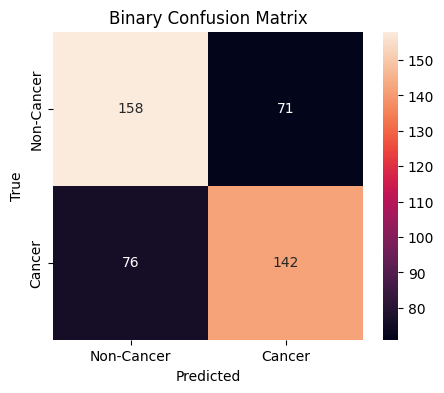


Classification Report:

              precision    recall  f1-score   support

  Non-Cancer       0.68      0.69      0.68       229
      Cancer       0.67      0.65      0.66       218

    accuracy                           0.67       447
   macro avg       0.67      0.67      0.67       447
weighted avg       0.67      0.67      0.67       447



In [24]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in val_ds_binary:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Non-Cancer", "Cancer"],
            yticklabels=["Non-Cancer", "Cancer"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Binary Confusion Matrix")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=["Non-Cancer", "Cancer"]))


In [26]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=32,
    label_mode="categorical"
)

print("Test dataset loaded ✅")


Found 118 files belonging to 9 classes.
Test dataset loaded ✅


In [27]:
test_ds_binary = test_ds.map(convert_to_binary)
test_ds_binary = test_ds_binary.prefetch(tf.data.AUTOTUNE)

print("Test dataset converted to binary ✅")


Test dataset converted to binary ✅


In [28]:
test_loss, test_accuracy = model.evaluate(test_ds_binary)

print("\nTest Accuracy:", test_accuracy)
print("Test Loss:", test_loss)


4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - accuracy: 0.6477 - loss: 0.6740

Test Accuracy: 0.6271186470985413
Test Loss: 0.7162970304489136


In [29]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds_binary:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

print("\nTest Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=["Non-Cancer", "Cancer"]))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step

Test Classification Report:

              precision    recall  f1-score   support

  Non-Cancer       0.56      0.83      0.67        54
      Cancer       0.76      0.45      0.57        64

    accuracy                           0.63       118
   macro avg       0.66      0.64      0.62       118
weighted avg       0.67      0.63      0.62       118



In [43]:
from google.colab import files
uploaded = files.upload()


Saving cancer.jpeg to cancer.jpeg


In [44]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Load image properly
img = image.load_img("cancer.jpeg", target_size=(224, 224))
img_array = image.img_to_array(img)

print("Before expand:", img_array.shape)  # should be (224,224,3)

# Expand to batch dimension
img_array = np.expand_dims(img_array, axis=0)

print("After expand:", img_array.shape)   # should be (1,224,224,3)

# Preprocess
img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

# Predict
prediction = model.predict(img_array)

print("Raw prediction:", prediction)


Before expand: (224, 224, 3)
After expand: (1, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Raw prediction: [[0.5831032]]


In [45]:
model.save("skin_binary_model.h5")


In [46]:
model.load_weights("skin_binary_model.h5")


In [47]:
prediction = model.predict(img_array)
print(prediction)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
[[0.5831032]]


In [48]:
threshold = 0.5

if prediction[0][0] > threshold:
    print(f"🔴 Cancer ({prediction[0][0]*100:.2f}% confidence)")
else:
    print(f"🟢 Non-Cancer ({(1-prediction[0][0])*100:.2f}% confidence)")


🔴 Cancer (58.31% confidence)


## Summary:

### Data Analysis Key Findings

*   **Overall Accuracy**: After an additional 15 epochs of fine-tuning, the overall accuracy on the validation dataset remained stable at 0.67, while the test dataset showed a slight improvement from 0.63 to 0.64.
*   **Validation Dataset - Class-specific Trade-offs**:
    *   The recall for "Non-Cancer" cases increased from 0.69 to 0.79, indicating better identification of true non-cancer instances. However, its precision slightly decreased from 0.68 to 0.65.
    *   Conversely, the precision for "Cancer" cases improved from 0.67 to 0.71, suggesting fewer false positives. However, the recall for "Cancer" cases decreased from 0.65 to 0.56, meaning more true cancer cases were missed.
*   **Test Dataset - Targeted Improvement in Cancer Recall**:
    *   The recall for the "Cancer" class improved from 0.45 to 0.52, a significant positive shift for a medical diagnostic task where detecting actual cancer cases is critical.
    *   Precision for "Cancer" remained high (0.76 before, 0.75 after), while "Non-Cancer" precision slightly increased from 0.56 to 0.58, and its recall slightly decreased from 0.83 to 0.80.

### Insights or Next Steps

*   While overall accuracy did not drastically change, the fine-tuning successfully shifted the model's performance to improve the crucial "Cancer" recall on the test set. This indicates a more medically useful model, even with some trade-offs in other metrics.
*   Future fine-tuning efforts could focus on optimizing for a balanced F1-score or explicitly weighting recall for the "Cancer" class higher during training to further improve its detection rate without sacrificing too much precision.